In [1]:
# Olist E-Commerce Sales & Operations — Python EDA

## Objective

#This notebook performs exploratory data analysis on the Olist Brazilian
#E-Commerce Public Dataset.

##The analysis focuses on:

#- Sales and order trends
#- Product and category performance
#- Delivery performance
#- Freight and order characteristics
#- Customer satisfaction
#- Payment behavior
#- Geographic patterns

#The analysis is performed using analysis-ready order-level and
#order-item-level datasets prepared from the original Olist tables.

In [3]:
# ============================================================
# REF 01 — Import Libraries and Configure Notebook
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
# ============================================================
# REF 02 — Load Order-Level and Order-Item-Level Data
# ============================================================

order_df = pd.read_csv(
    "data/processed/olist_order_level_analysis.csv"
)

item_df = pd.read_csv(
    "data/processed/olist_order_item_analysis.csv"
)

print("Order-level shape:", order_df.shape)
print("Order-item shape:", item_df.shape)

Order-level shape: (99441, 31)
Order-item shape: (112650, 27)


In [5]:
# ============================================================
# REF 03 — Inspect Dataset Columns
# ============================================================

print("ORDER-LEVEL COLUMNS")
print(order_df.columns.tolist())

print("\nORDER-ITEM COLUMNS")
print(item_df.columns.tolist())

ORDER-LEVEL COLUMNS
['order_id', 'customer_id', 'customer_unique_id', 'customer_city', 'customer_state', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'total_product_value', 'total_freight_value', 'total_order_value', 'item_count', 'product_count', 'seller_count', 'payment_value', 'payment_record_count', 'payment_type_count', 'payment_types', 'max_installments', 'review_count', 'average_review_score', 'delivery_days', 'estimated_delivery_days', 'delivery_delay_days', 'approval_delay_hours', 'carrier_delivery_days', 'delivery_performance', 'customer_order_count']

ORDER-ITEM COLUMNS
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'produ

In [6]:
# ============================================================
# REF 04 — Inspect Data Types
# ============================================================

print("ORDER-LEVEL DATA TYPES")
print(order_df.dtypes)

print("\nORDER-ITEM DATA TYPES")
print(item_df.dtypes)

ORDER-LEVEL DATA TYPES
order_id                             str
customer_id                          str
customer_unique_id                   str
customer_city                        str
customer_state                       str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
total_product_value              float64
total_freight_value              float64
total_order_value                float64
item_count                       float64
product_count                    float64
seller_count                     float64
payment_value                    float64
payment_record_count             float64
payment_type_count               float64
payment_types                        str
max_installments                 float64
review_count                     float64
average_review_score             f

In [7]:
# ============================================================
# REF 05 — Check Missing Values
# ============================================================

order_missing = (
    order_df.isna()
    .sum()
    .sort_values(ascending=False)
)

item_missing = (
    item_df.isna()
    .sum()
    .sort_values(ascending=False)
)

print("ORDER-LEVEL MISSING VALUES")
print(order_missing[order_missing > 0])

print("\nORDER-ITEM MISSING VALUES")
print(item_missing[item_missing > 0])

ORDER-LEVEL MISSING VALUES
delivery_days                    2965
delivery_delay_days              2965
order_delivered_customer_date    2965
carrier_delivery_days            1783
order_delivered_carrier_date     1783
product_count                     775
seller_count                      775
item_count                        775
total_order_value                 775
total_freight_value               775
total_product_value               775
review_count                      768
average_review_score              768
order_approved_at                 160
approval_delay_hours              160
payment_value                       1
payment_record_count                1
payment_type_count                  1
payment_types                       1
max_installments                    1
dtype: int64

ORDER-ITEM MISSING VALUES
order_delivered_customer_date    2454
product_category_name_english    1627
product_name_lenght              1603
product_description_lenght       1603
product_category_name

In [8]:
# ============================================================
# REF 06 — Validate Order-Level Dataset Grain
# ============================================================

print("Total rows:", len(order_df))
print("Unique order IDs:", order_df["order_id"].nunique())
print("Duplicate order IDs:", order_df["order_id"].duplicated().sum())

if (
    len(order_df)
    == order_df["order_id"].nunique()
    and order_df["order_id"].duplicated().sum() == 0
):
    print("Order-level grain validated: 1 row = 1 order.")
else:
    print("WARNING: Order-level grain requires investigation.")


Total rows: 99441
Unique order IDs: 99441
Duplicate order IDs: 0
Order-level grain validated: 1 row = 1 order.


In [9]:
# ============================================================
# REF 07 — Validate Order-Item-Level Dataset Grain
# ============================================================

print("Total rows:", len(item_df))
print("Unique order IDs:", item_df["order_id"].nunique())
print("Unique order_item_id values:", item_df["order_item_id"].nunique())

item_df["item_key"] = (
    item_df["order_id"].astype(str)
    + "_"
    + item_df["order_item_id"].astype(str)
)

print("Unique composite item keys:", item_df["item_key"].nunique())
print("Duplicate composite item keys:", item_df["item_key"].duplicated().sum())

if item_df["item_key"].duplicated().sum() == 0:
    print("Order-item grain validated: 1 row = 1 order item.")
else:
    print("WARNING: Duplicate order-item keys detected.")

Total rows: 112650
Unique order IDs: 98666
Unique order_item_id values: 21
Unique composite item keys: 112650
Duplicate composite item keys: 0
Order-item grain validated: 1 row = 1 order item.


In [10]:
# ============================================================
# REF 08 — Convert Order Date Columns to Datetime
# ============================================================

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    order_df[col] = pd.to_datetime(
        order_df[col],
        errors="coerce"
    )

print(order_df[date_columns].dtypes)

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [11]:
# ============================================================
# REF 09 — Identify Observation Period
# ============================================================

print(
    "Purchase date range:",
    order_df["order_purchase_timestamp"].min(),
    "to",
    order_df["order_purchase_timestamp"].max()
)


Purchase date range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18


In [12]:
# ============================================================
# REF 10 — Create Monthly Order Period
# ============================================================

order_df["purchase_month"] = (
    order_df["order_purchase_timestamp"]
    .dt.to_period("M")
)

print(order_df[
    [
        "order_purchase_timestamp",
        "purchase_month"
    ]
].head())

  order_purchase_timestamp purchase_month
0      2017-10-02 10:56:33        2017-10
1      2018-07-24 20:41:37        2018-07
2      2018-08-08 08:38:49        2018-08
3      2017-11-18 19:28:06        2017-11
4      2018-02-13 21:18:39        2018-02


In [13]:
# ============================================================
# REF 11 — Calculate Monthly Sales and Order Metrics
# ============================================================

monthly_orders = (
    order_df
    .groupby("purchase_month")
    .agg(
        order_count=("order_id", "count"),
        product_value=("total_product_value", "sum"),
        freight_value=("total_freight_value", "sum"),
        total_order_value=("total_order_value", "sum")
    )
    .reset_index()
)

monthly_orders["average_order_value"] = (
    monthly_orders["total_order_value"]
    / monthly_orders["order_count"]
)

print(monthly_orders.head())
print("\nLatest months:")
print(monthly_orders.tail())

  purchase_month  order_count  product_value  freight_value  \
0        2016-09            4         267.36          87.39   
1        2016-10          324      49,507.66       7,301.18   
2        2016-12            1          10.90           8.72   
3        2017-01          800     120,312.87      16,875.62   
4        2017-02         1780     247,303.02      38,977.60   

   total_order_value  average_order_value  
0             354.75                88.69  
1          56,808.84               175.34  
2              19.62                19.62  
3         137,188.49               171.49  
4         286,280.62               160.83  

Latest months:
   purchase_month  order_count  product_value  freight_value  \
20        2018-06         6167     865,124.31     157,552.80   
21        2018-07         6292     895,507.22     163,220.81   
22        2018-08         6512     854,686.33     148,622.14   
23        2018-09           16         145.00          21.46   
24        2018-10    

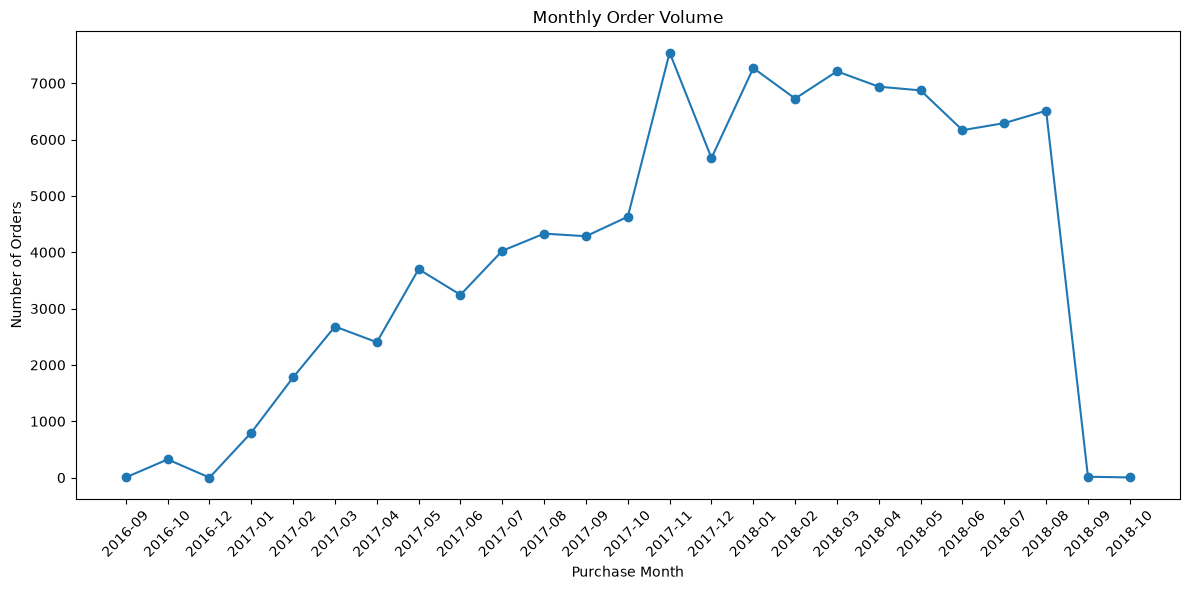

In [14]:
# ============================================================
# REF 12 — Visualize Monthly Order Volume
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_orders["purchase_month"].astype(str),
    monthly_orders["order_count"],
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Purchase Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

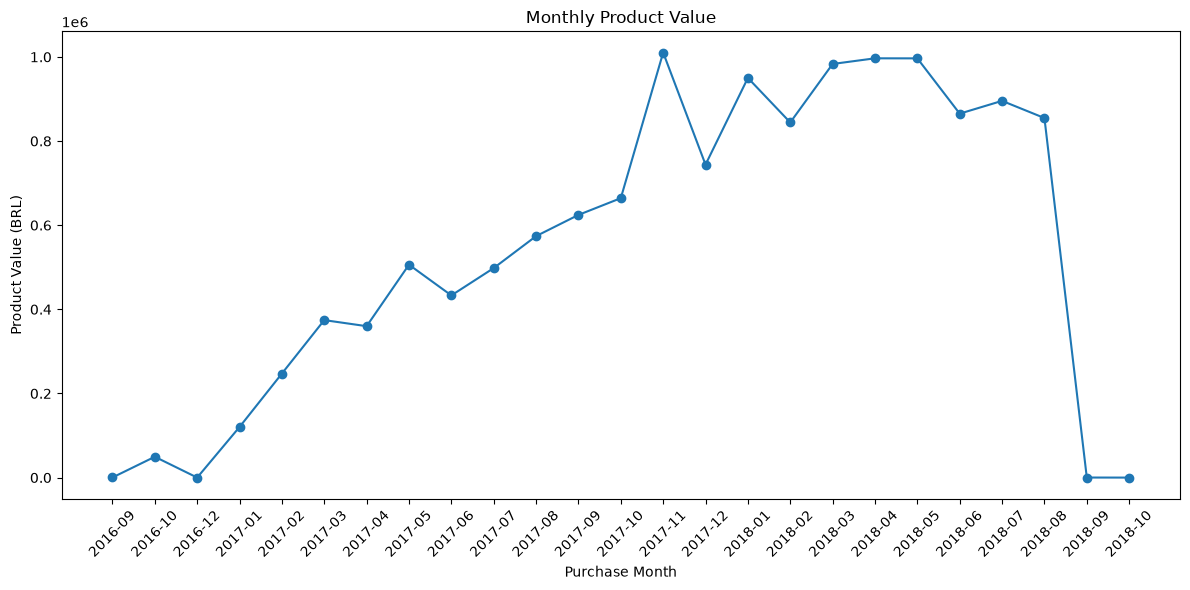

In [15]:
# ============================================================
# REF 13 — Visualize Monthly Product Value
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_orders["purchase_month"].astype(str),
    monthly_orders["product_value"],
    marker="o"
)

plt.title("Monthly Product Value")
plt.xlabel("Purchase Month")
plt.ylabel("Product Value (BRL)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# REF 14 — Calculate Overall Sales Metrics
# ============================================================

print("Total orders:", monthly_orders["order_count"].sum())
print(
    "Total product value:",
    monthly_orders["product_value"].sum()
)
print(
    "Total freight:",
    monthly_orders["freight_value"].sum()
)
print(
    "Total order value:",
    monthly_orders["total_order_value"].sum()
)

Total orders: 99441
Total product value: 13591643.7
Total freight: 2251909.54
Total order value: 15843553.240000002


In [17]:
# ============================================================
# REF 15 — Calculate Product Category Performance
# ============================================================

category_summary = (
    item_df
    .groupby(
        "product_category_name_english",
        dropna=False
    )
    .agg(
        item_count=("order_item_id", "count"),
        product_value=("price", "sum"),
        freight_value=("freight_value", "sum"),
        average_price=("price", "mean")
    )
    .reset_index()
)

category_summary["freight_percentage"] = np.where(
    category_summary["product_value"] != 0,
    (
        category_summary["freight_value"]
        / category_summary["product_value"]
        * 100
    ),
    np.nan
)

print(category_summary.head(10))
print("\nNumber of categories:", len(category_summary))
print(
    "Missing category values:",
    category_summary[
        "product_category_name_english"
    ].isna().sum()
)

  product_category_name_english  item_count  product_value  freight_value  \
0    agro_industry_and_commerce         212      72,530.47       5,843.60   
1              air_conditioning         297      55,024.96       6,749.23   
2                           art         209      24,202.64       4,045.17   
3         arts_and_craftmanship          24       1,814.01         370.13   
4                         audio         364      50,688.50       5,710.44   
5                          auto        4235     592,720.11      92,664.21   
6                          baby        3065     411,764.89      68,353.11   
7                bed_bath_table       11115   1,036,988.68     204,693.04   
8        books_general_interest         553      46,856.88       9,195.52   
9                books_imported          60       4,639.85         769.85   

   average_price  freight_percentage  
0         342.12                8.06  
1         185.27               12.27  
2         115.80               16.7

In [18]:
# ============================================================
# REF 16 — Top 10 Product Categories by Product Value
# ============================================================

top_categories_value = (
    category_summary[
        category_summary[
            "product_category_name_english"
        ].notna()
    ]
    .sort_values(
        "product_value",
        ascending=False
    )
    .head(10)
)

print(top_categories_value)

   product_category_name_english  item_count  product_value  freight_value  \
43                 health_beauty        9670   1,258,681.34     182,566.73   
70                 watches_gifts        5991   1,205,005.68     100,535.93   
7                 bed_bath_table       11115   1,036,988.68     204,693.04   
65                sports_leisure        8641     988,048.97     168,607.51   
15         computers_accessories        7827     911,954.32     147,318.08   
39               furniture_decor        8334     729,762.49     172,749.30   
20                    cool_stuff        3796     635,290.85      84,039.10   
49                    housewares        6964     632,248.66     146,149.11   
5                           auto        4235     592,720.11      92,664.21   
42                  garden_tools        4347     485,256.46      98,962.75   

    average_price  freight_percentage  
43         130.16               14.50  
70         201.14                8.34  
7           93.30    

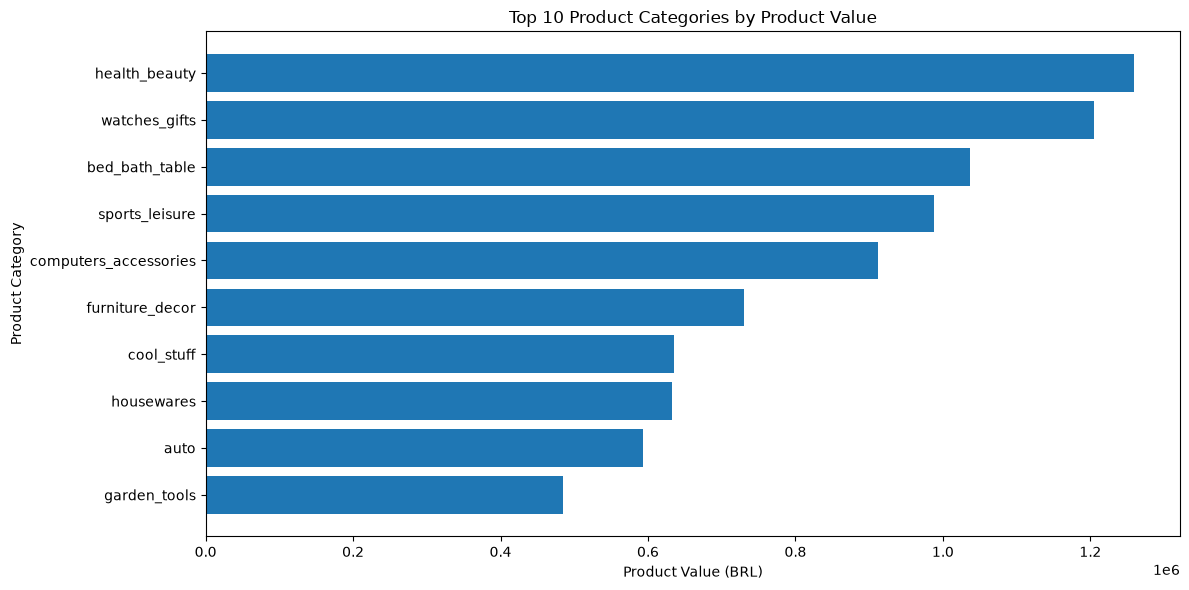

In [19]:
# ============================================================
# REF 17 — Visualize Top 10 Categories by Product Value
# ============================================================

plt.figure(figsize=(12, 6))

plt.barh(
    top_categories_value[
        "product_category_name_english"
    ][::-1],
    top_categories_value[
        "product_value"
    ][::-1]
)

plt.title("Top 10 Product Categories by Product Value")
plt.xlabel("Product Value (BRL)")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# REF 18 — Top 10 Product Categories by Item Volume
# ============================================================

top_categories_volume = (
    category_summary[
        category_summary[
            "product_category_name_english"
        ].notna()
    ]
    .sort_values(
        "item_count",
        ascending=False
    )
    .head(10)
)

print(top_categories_volume)

   product_category_name_english  item_count  product_value  freight_value  \
7                 bed_bath_table       11115   1,036,988.68     204,693.04   
43                 health_beauty        9670   1,258,681.34     182,566.73   
65                sports_leisure        8641     988,048.97     168,607.51   
39               furniture_decor        8334     729,762.49     172,749.30   
15         computers_accessories        7827     911,954.32     147,318.08   
49                    housewares        6964     632,248.66     146,149.11   
70                 watches_gifts        5991   1,205,005.68     100,535.93   
68                     telephony        4545     323,667.53      71,215.79   
42                  garden_tools        4347     485,256.46      98,962.75   
5                           auto        4235     592,720.11      92,664.21   

    average_price  freight_percentage  
7           93.30               19.74  
43         130.16               14.50  
65         114.34    

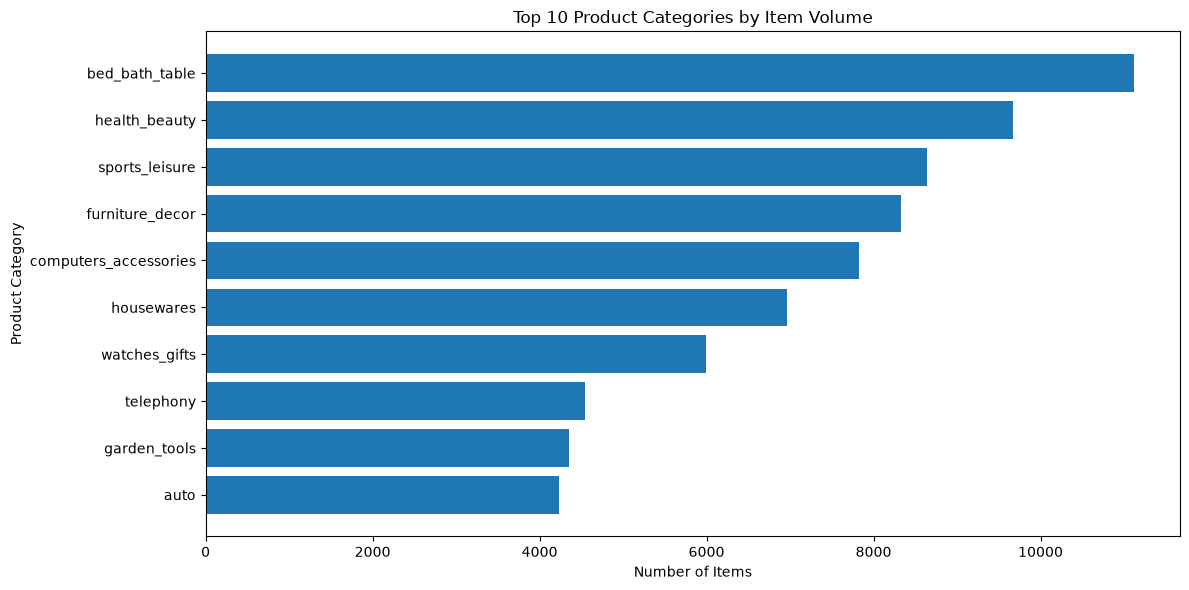

In [21]:
# ============================================================
# REF 19 — Visualize Top 10 Categories by Item Volume
# ============================================================

plt.figure(figsize=(12, 6))

plt.barh(
    top_categories_volume[
        "product_category_name_english"
    ][::-1],
    top_categories_volume[
        "item_count"
    ][::-1]
)

plt.title("Top 10 Product Categories by Item Volume")
plt.xlabel("Number of Items")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()


In [22]:
# ============================================================
# REF 20 — Identify Categories with High Freight-to-Product Value
# ============================================================

high_freight_categories = (
    category_summary[
        category_summary[
            "product_category_name_english"
        ].notna()
        & (category_summary["product_value"] > 0)
    ]
    .sort_values(
        "freight_percentage",
        ascending=False
    )
    .head(10)
)

print(high_freight_categories)

        product_category_name_english  item_count  product_value  \
46                     home_comfort_2          30         760.27   
35                            flowers          33       1,110.04   
41  furniture_mattress_and_upholstery          38       4,368.08   
12                 christmas_supplies         153       8,800.82   
23                diapers_and_hygiene          39       1,567.59   
11                  cds_dvds_musicals          14         730.00   
62             signaling_and_security         199      21,509.23   
37                         food_drink         278      15,179.48   
26                        electronics        2767     160,246.74   
32                      fashion_sport          30       2,119.51   

    freight_value  average_price  freight_percentage  
46         410.31          25.34               53.97  
35         488.87          33.64               44.04  
41       1,630.46         114.95               37.33  
12       3,229.30          57.5

In [23]:
# ============================================================
# REF 21 — Validate Category Totals Against Item-Level Totals
# ============================================================

item_product_value = item_df["price"].sum()
category_product_value = category_summary["product_value"].sum()

item_freight = item_df["freight_value"].sum()
category_freight = category_summary["freight_value"].sum()

print("Item-level product value:", item_product_value)
print("Category-level product value:", category_product_value)

print("\nItem-level freight:", item_freight)
print("Category-level freight:", category_freight)

print(
    "\nProduct value reconciliation:",
    np.isclose(
        item_product_value,
        category_product_value
    )
)

print(
    "Freight reconciliation:",
    np.isclose(
        item_freight,
        category_freight
    )
)


Item-level product value: 13591643.7
Category-level product value: 13591643.7

Item-level freight: 2251909.54
Category-level freight: 2251909.54

Product value reconciliation: True
Freight reconciliation: True


In [24]:
# ============================================================
# REF 22 — Analyze Delivery Performance
# ============================================================

delivery_summary = (
    order_df
    .groupby(
        "delivery_performance",
        dropna=False
    )
    .agg(
        order_count=("order_id", "count"),
        average_delivery_days=(
            "delivery_days",
            "mean"
        ),
        average_delay_days=(
            "delivery_delay_days",
            "mean"
        ),
        average_review_score=(
            "average_review_score",
            "mean"
        )
    )
    .reset_index()
)

delivery_summary["order_percentage"] = (
    delivery_summary["order_count"]
    / len(order_df)
    * 100
)

delivery_summary


,delivery_performance,order_count,average_delivery_days,average_delay_days,average_review_score,order_percentage
0,Early,88649,10.88,-13.01,4.29,89.15
1,Late,7827,31.52,9.55,2.57,7.87
2,Not Delivered,2965,NaN,NaN,1.75,2.98


In [25]:
# ============================================================
# REF 23 — Analyze Customer Review Score Distribution
# ============================================================

review_distribution = (
    order_df["average_review_score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

review_distribution.columns = [
    "review_score",
    "order_count"
]

review_distribution["percentage"] = (
    review_distribution["order_count"]
    / review_distribution["order_count"].sum()
    * 100
)

review_distribution

,review_score,order_count,percentage
0,1.00,11316,11.47
1,1.50,8,0.01
2,2.00,3125,3.17
3,2.50,34,0.03
4,3.00,8136,8.25
5,3.33,1,0.00
6,3.50,25,0.03
7,4.00,19018,19.27
8,4.33,1,0.00
9,4.50,54,0.05


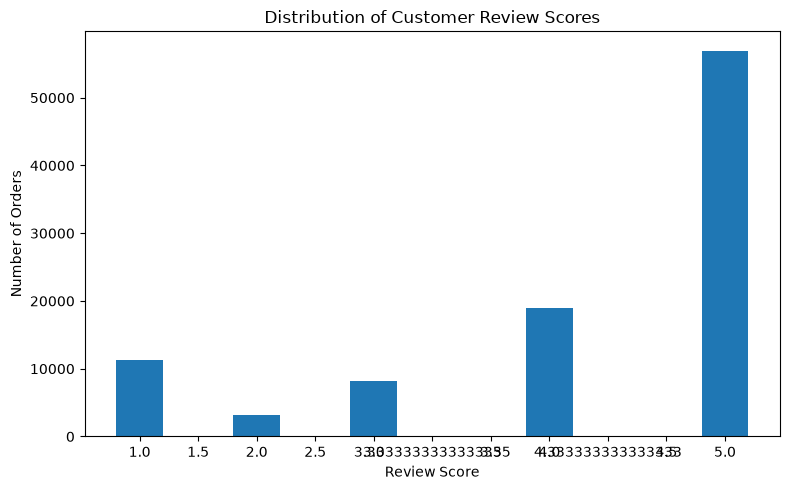

In [26]:
# ============================================================
# REF 24 — Visualize Customer Review Score Distribution
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    review_distribution["review_score"].astype(str),
    review_distribution["order_count"]
)

plt.title("Distribution of Customer Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# REF 25 — Compare Delivery Performance with Review Scores
# ============================================================

delivery_review = (
    order_df
    .groupby("delivery_performance")
    .agg(
        order_count=("order_id", "count"),
        average_review_score=(
            "average_review_score",
            "mean"
        )
    )
    .reset_index()
)

delivery_review

,delivery_performance,order_count,average_review_score
0,Early,88649,4.29
1,Late,7827,2.57
2,Not Delivered,2965,1.75


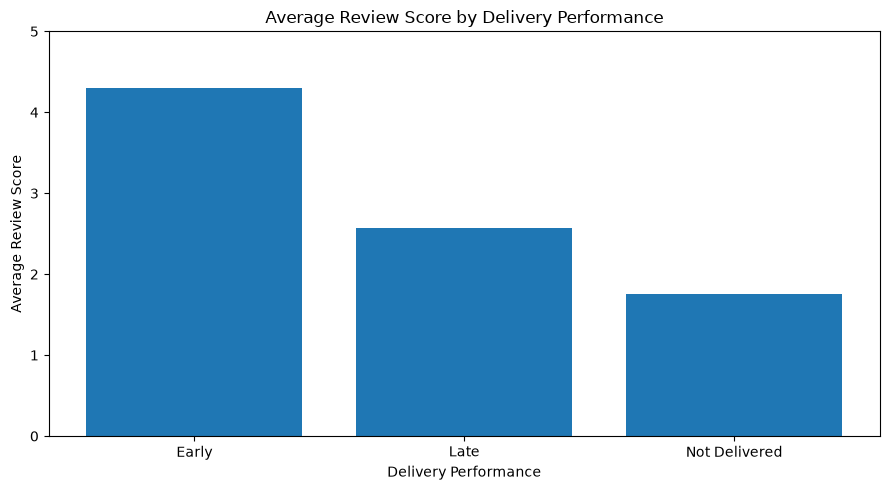

In [28]:
# ============================================================
# REF 26 — Visualize Average Review Score by Delivery Performance
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    delivery_review["delivery_performance"],
    delivery_review["average_review_score"]
)

plt.title(
    "Average Review Score by Delivery Performance"
)
plt.xlabel("Delivery Performance")
plt.ylabel("Average Review Score")

plt.ylim(0, 5)

plt.tight_layout()
plt.show()


In [29]:
# ============================================================
# REF 27 — Review Score Distribution by Delivery Performance
# ============================================================

review_by_delivery = pd.crosstab(
    order_df["delivery_performance"],
    order_df["average_review_score"],
    normalize="index"
) * 100

review_by_delivery.round(2)

average_review_score,1.00,1.50,2.00,2.50,3.00,3.33,3.50,4.00,4.33,4.50,5.00
delivery_performance,,,,,,,,,,,
Early,6.56,0.01,2.62,0.03,7.99,0.00,0.02,20.33,0.00,0.06,62.38
Late,46.11,0.01,7.86,0.08,11.34,0.00,0.04,12.33,0.00,0.03,22.20
Not Delivered,70.35,0.00,7.35,0.14,7.74,0.00,0.07,5.28,0.00,0.04,9.04


In [30]:
# ============================================================
# REF 28 — Prepare Complete Delivery Delay and Review Data
# ============================================================

delay_review = order_df[
    [
        "order_id",
        "delivery_delay_days",
        "average_review_score"
    ]
].dropna(
    subset=[
        "delivery_delay_days",
        "average_review_score"
    ]
).copy()

print("Rows available for delay-review analysis:", len(delay_review))

Rows available for delay-review analysis: 95830


In [31]:
# ============================================================
# REF 29 — Analyze Delivery Delay by Review Score
# ============================================================

delay_review_summary = (
    delay_review
    .groupby("average_review_score")
    .agg(
        order_count=("order_id", "count"),
        average_delay_days=(
            "delivery_delay_days",
            "mean"
        ),
        median_delay_days=(
            "delivery_delay_days",
            "median"
        )
    )
    .reset_index()
)

delay_review_summary

,average_review_score,order_count,average_delay_days,median_delay_days
0,1.00,9316,-3.34,-6.37
1,1.50,8,-5.34,-8.82
2,2.00,2916,-7.94,-9.31
3,2.50,30,-6.82,-10.25
4,3.00,7916,-10.08,-10.36
5,3.33,1,-13.09,-13.09
6,3.50,23,-13.22,-12.16
7,4.00,18868,-11.68,-11.49
8,4.33,1,-10.29,-10.29
9,4.50,53,-12.36,-12.42


In [32]:
# ============================================================
# REF 30 — Examine Correlation Between Delivery Delay and Review
# ============================================================

delay_review_corr = (
    delay_review[
        [
            "delivery_delay_days",
            "average_review_score"
        ]
    ]
    .corr()
)

delay_review_corr

,delivery_delay_days,average_review_score
delivery_delay_days,1.00,-0.27
average_review_score,-0.27,1.00


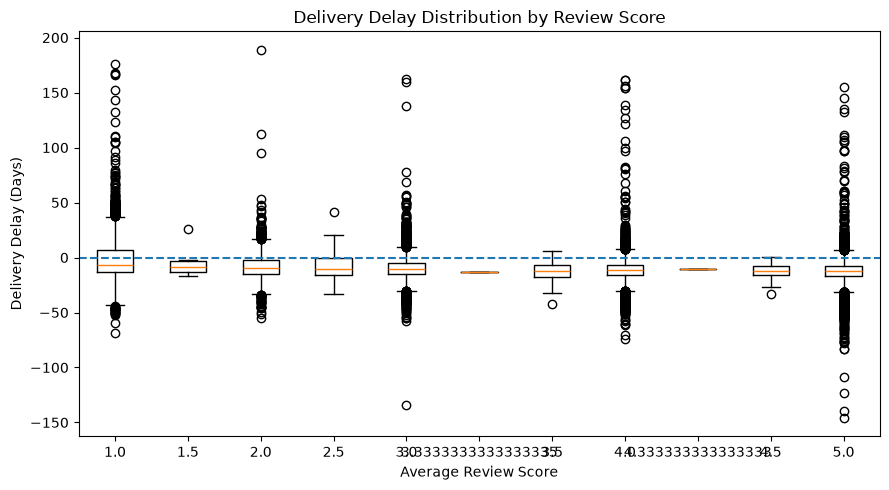

In [33]:
# ============================================================
# REF 31 — Visualize Delivery Delay Distribution by Review Score
# ============================================================

scores = sorted(
    delay_review["average_review_score"]
    .dropna()
    .unique()
)

delay_groups = [
    delay_review[
        delay_review["average_review_score"] == score
    ]["delivery_delay_days"]
    for score in scores
]

plt.figure(figsize=(9, 5))

plt.boxplot(
    delay_groups,
    tick_labels=[str(score) for score in scores]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Delivery Delay Distribution by Review Score"
)
plt.xlabel("Average Review Score")
plt.ylabel("Delivery Delay (Days)")

plt.tight_layout()
plt.show()


In [34]:
# ============================================================
# REF 32 — Analyze Freight Value by Review Score
# ============================================================

freight_review_summary = (
    order_df
    .groupby("average_review_score")
    .agg(
        order_count=("order_id", "count"),
        average_freight=(
            "total_freight_value",
            "mean"
        ),
        median_freight=(
            "total_freight_value",
            "median"
        ),
        average_order_value=(
            "total_order_value",
            "mean"
        )
    )
    .reset_index()
)

freight_review_summary


,average_review_score,order_count,average_freight,median_freight,average_order_value
0,1.00,11316,27.75,18.45,194.72
1,1.50,8,38.57,38.66,204.70
2,2.00,3125,26.25,18.02,171.86
3,2.50,34,25.40,18.23,133.23
4,3.00,8136,23.56,17.63,151.20
5,3.33,1,16.11,16.11,42.11
6,3.50,25,21.34,16.30,143.65
7,4.00,19018,22.37,17.19,154.86
8,4.33,1,7.78,7.78,42.77
9,4.50,54,23.31,17.74,121.89


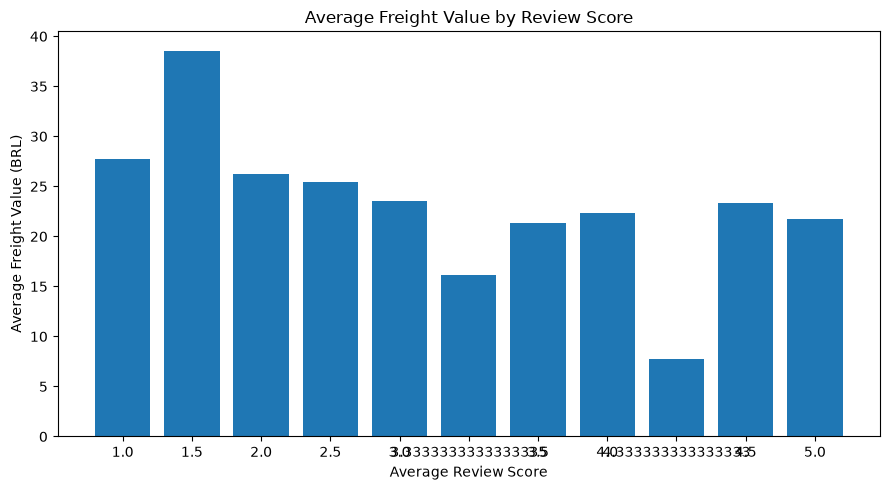

In [35]:
# ============================================================
# REF 33 — Visualize Average Freight Value by Review Score
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    freight_review_summary[
        "average_review_score"
    ].astype(str),
    freight_review_summary[
        "average_freight"
    ]
)

plt.title(
    "Average Freight Value by Review Score"
)
plt.xlabel("Average Review Score")
plt.ylabel("Average Freight Value (BRL)")

plt.tight_layout()
plt.show()

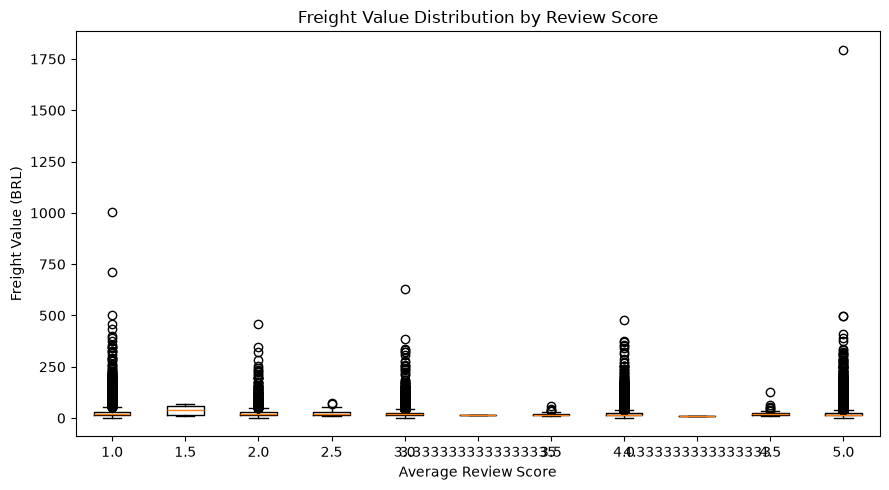

In [36]:
# ============================================================
# REF 34 — Visualize Freight Distribution by Review Score
# ============================================================

scores = sorted(
    order_df["average_review_score"]
    .dropna()
    .unique()
)

freight_groups = [
    order_df[
        order_df["average_review_score"] == score
    ]["total_freight_value"]
    .dropna()
    for score in scores
]

plt.figure(figsize=(9, 5))

plt.boxplot(
    freight_groups,
    tick_labels=[str(score) for score in scores]
)

plt.title(
    "Freight Value Distribution by Review Score"
)
plt.xlabel("Average Review Score")
plt.ylabel("Freight Value (BRL)")

plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# REF 35 — Examine Freight Value and Review Score Correlation
# ============================================================

freight_review_corr = (
    order_df[
        [
            "total_freight_value",
            "average_review_score"
        ]
    ]
    .dropna()
    .corr()
)

freight_review_corr

,total_freight_value,average_review_score
total_freight_value,1.00,-0.09
average_review_score,-0.09,1.00


In [38]:
# ============================================================
# REF 36 — Calculate Freight as Percentage of Product Value
# ============================================================

order_df["freight_percentage"] = np.where(
    order_df["total_product_value"] != 0,
    (
        order_df["total_freight_value"]
        / order_df["total_product_value"]
        * 100
    ),
    np.nan
)

print(
    "Missing freight percentage:",
    order_df["freight_percentage"].isna().sum()
)

print(
    "Infinite freight percentage:",
    np.isinf(
        order_df["freight_percentage"]
    ).sum()
)

print(
    "\nFreight percentage statistics:"
)

print(
    order_df["freight_percentage"].describe()
)

Missing freight percentage: 775
Infinite freight percentage: 0

Freight percentage statistics:
count   98,666.00
mean        30.84
std         31.48
min          0.00
25%         13.19
50%         22.44
75%         38.02
max      2,144.71
Name: freight_percentage, dtype: float64


In [39]:
# ============================================================
# REF 37 — Analyze Freight Percentage by Review Score
# ============================================================

freight_ratio_review = (
    order_df
    .groupby("average_review_score")
    .agg(
        order_count=("order_id", "count"),
        average_freight_percentage=(
            "freight_percentage",
            "mean"
        ),
        median_freight_percentage=(
            "freight_percentage",
            "median"
        )
    )
    .reset_index()
)

freight_ratio_review

,average_review_score,order_count,average_freight_percentage,median_freight_percentage
0,1.00,11316,31.67,22.76
1,1.50,8,27.46,25.69
2,2.00,3125,32.30,23.50
3,2.50,34,37.82,25.76
4,3.00,8136,32.56,23.73
5,3.33,1,61.96,61.96
6,3.50,25,29.28,22.02
7,4.00,19018,31.31,22.53
8,4.33,1,22.23,22.23
9,4.50,54,42.87,27.08


In [40]:
# ============================================================
# REF 38 — Analyze Order Value by Review Score
# ============================================================

order_value_review = (
    order_df
    .groupby("average_review_score")
    .agg(
        order_count=("order_id", "count"),
        average_order_value=(
            "total_order_value",
            "mean"
        ),
        median_order_value=(
            "total_order_value",
            "median"
        )
    )
    .reset_index()
)

order_value_review

,average_review_score,order_count,average_order_value,median_order_value
0,1.00,11316,194.72,120.98
1,1.50,8,204.70,175.08
2,2.00,3125,171.86,112.50
3,2.50,34,133.23,110.25
4,3.00,8136,151.20,103.14
5,3.33,1,42.11,42.11
6,3.50,25,143.65,121.90
7,4.00,19018,154.86,102.84
8,4.33,1,42.77,42.77
9,4.50,54,121.89,84.68


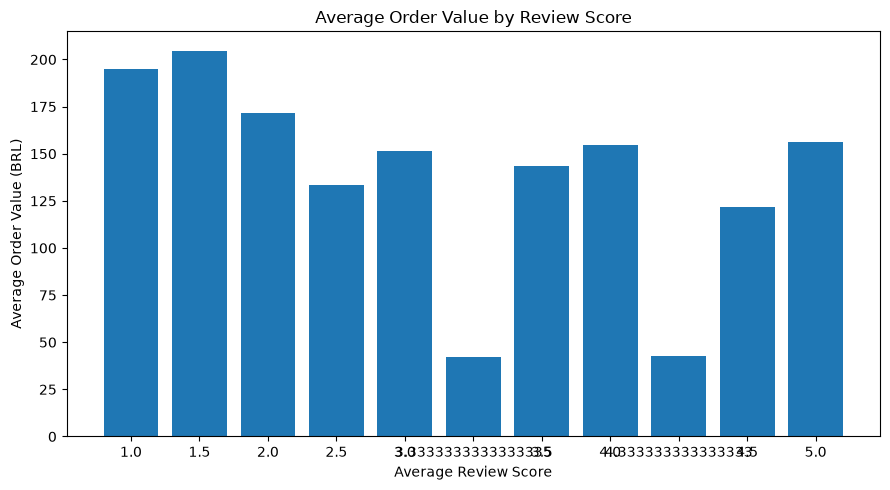

In [41]:
# ============================================================
# REF 39 — Visualize Average Order Value by Review Score
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    order_value_review[
        "average_review_score"
    ].astype(str),
    order_value_review[
        "average_order_value"
    ]
)

plt.title(
    "Average Order Value by Review Score"
)
plt.xlabel("Average Review Score")
plt.ylabel("Average Order Value (BRL)")

plt.tight_layout()
plt.show()


In [42]:
# ============================================================
# REF 40 — Analyze Number of Items per Order by Review Score
# ============================================================

items_review = (
    order_df
    .groupby("average_review_score")
    .agg(
        order_count=("order_id", "count"),
        average_item_count=(
            "item_count",
            "mean"
        ),
        median_item_count=(
            "item_count",
            "median"
        )
    )
    .reset_index()
)

items_review

,average_review_score,order_count,average_item_count,median_item_count
0,1.00,11316,1.31,1.00
1,1.50,8,2.25,2.00
2,2.00,3125,1.25,1.00
3,2.50,34,1.36,1.00
4,3.00,8136,1.16,1.00
5,3.33,1,1.00,1.00
6,3.50,25,1.24,1.00
7,4.00,19018,1.11,1.00
8,4.33,1,1.00,1.00
9,4.50,54,1.26,1.00


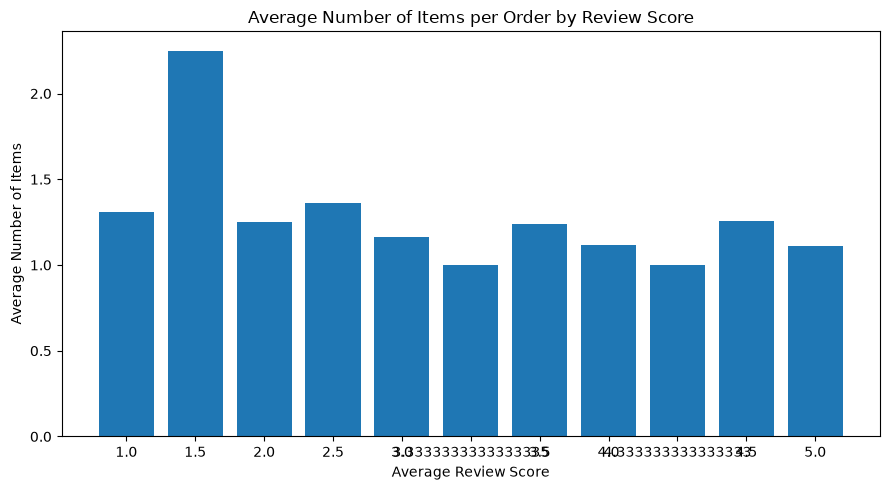

In [43]:
# ============================================================
# REF 41 — Visualize Average Items per Order by Review Score
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    items_review[
        "average_review_score"
    ].astype(str),
    items_review[
        "average_item_count"
    ]
)

plt.title(
    "Average Number of Items per Order by Review Score"
)
plt.xlabel("Average Review Score")
plt.ylabel("Average Number of Items")

plt.tight_layout()
plt.show()

In [44]:
# ============================================================
# REF 42 — Analyze Product Count per Order by Review Score
# ============================================================

products_review = (
    order_df
    .groupby("average_review_score")
    .agg(
        order_count=("order_id", "count"),
        average_product_count=(
            "product_count",
            "mean"
        ),
        median_product_count=(
            "product_count",
            "median"
        )
    )
    .reset_index()
)

products_review

,average_review_score,order_count,average_product_count,median_product_count
0,1.00,11316,1.09,1.00
1,1.50,8,1.75,1.50
2,2.00,3125,1.09,1.00
3,2.50,34,1.18,1.00
4,3.00,8136,1.05,1.00
5,3.33,1,1.00,1.00
6,3.50,25,1.12,1.00
7,4.00,19018,1.03,1.00
8,4.33,1,1.00,1.00
9,4.50,54,1.07,1.00


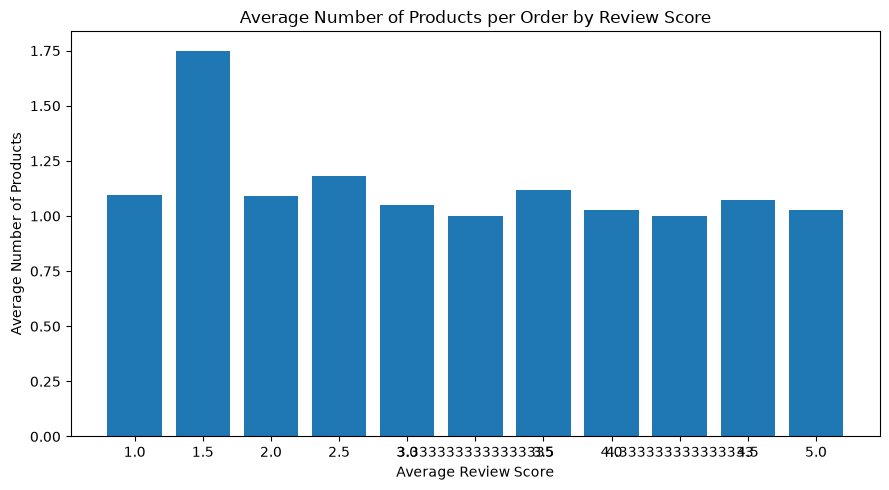

In [45]:
# ============================================================
# REF 43 — Visualize Average Product Count by Review Score
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    products_review[
        "average_review_score"
    ].astype(str),
    products_review[
        "average_product_count"
    ]
)

plt.title(
    "Average Number of Products per Order by Review Score"
)
plt.xlabel("Average Review Score")
plt.ylabel("Average Number of Products")

plt.tight_layout()
plt.show()


In [46]:
# ============================================================
# REF 44 — Calculate Correlation Matrix of Key Variables
# ============================================================

correlation_columns = [
    "total_product_value",
    "total_freight_value",
    "total_order_value",
    "item_count",
    "product_count",
    "delivery_delay_days",
    "average_review_score"
]

correlation_data = order_df[
    correlation_columns
].dropna()

correlation_matrix = correlation_data.corr()

correlation_matrix.round(3)

,total_product_value,total_freight_value,total_order_value,item_count,product_count,delivery_delay_days,average_review_score
total_product_value,1.00,0.41,1.00,0.15,0.06,-0.01,-0.04
total_freight_value,0.41,1.00,0.49,0.44,0.20,-0.05,-0.09
total_order_value,1.00,0.49,1.00,0.19,0.08,-0.02,-0.04
item_count,0.15,0.44,0.19,1.00,0.48,-0.03,-0.12
product_count,0.06,0.20,0.08,0.48,1.00,-0.05,-0.11
delivery_delay_days,-0.01,-0.05,-0.02,-0.03,-0.05,1.00,-0.27
average_review_score,-0.04,-0.09,-0.04,-0.12,-0.11,-0.27,1.00


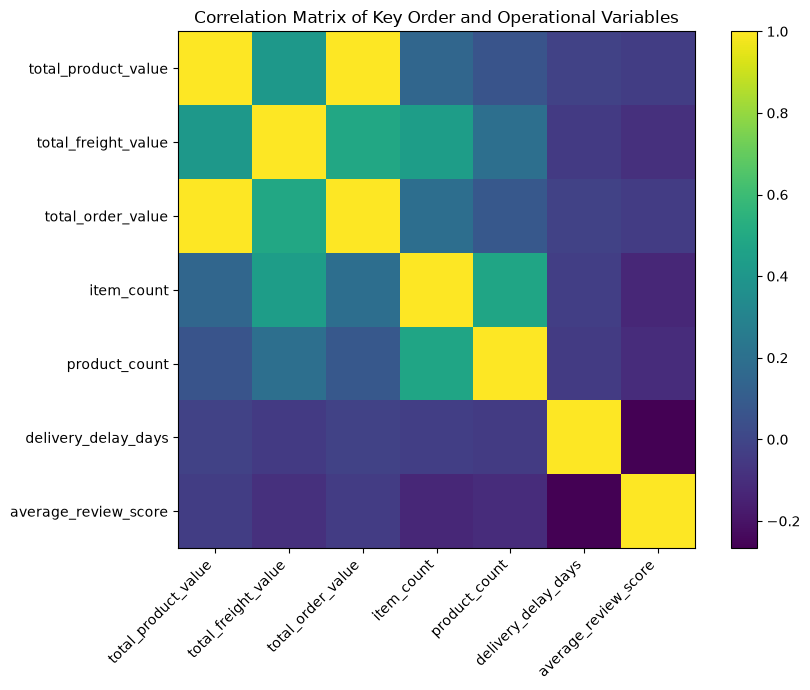

In [47]:
# ============================================================
# REF 45 — Visualize Correlation Matrix
# ============================================================

plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title(
    "Correlation Matrix of Key Order and Operational Variables"
)

plt.tight_layout()
plt.show()


In [48]:
# ============================================================
# REF 46 — Analyze Customer Order Frequency and Review Score
# ============================================================

customer_frequency_review = (
    order_df
    .groupby("customer_order_count")
    .agg(
        order_count=("order_id", "count"),
        average_review_score=(
            "average_review_score",
            "mean"
        )
    )
    .reset_index()
)

print(customer_frequency_review.head(10))

print("\nCustomer order frequency distribution:")
print(
    order_df[
        "customer_order_count"
    ]
    .value_counts()
    .sort_index()
    .head(15)
)


   customer_order_count  order_count  average_review_score
0                     1        99441                  4.09

Customer order frequency distribution:
customer_order_count
1    99441
Name: count, dtype: int64


In [49]:
# ============================================================
# REF 47 — Spearman Correlation: Delivery Delay vs Review Score
# ============================================================

delay_corr_data = order_df[
    [
        "delivery_delay_days",
        "average_review_score"
    ]
].dropna()

spearman_delay = stats.spearmanr(
    delay_corr_data["delivery_delay_days"],
    delay_corr_data["average_review_score"]
)

print(
    "Spearman correlation:",
    spearman_delay.statistic
)

print(
    "p-value:",
    spearman_delay.pvalue
)

Spearman correlation: -0.17557025450037278
p-value: 0.0


In [50]:
# ============================================================
# REF 48 — Kruskal-Wallis Test: Delivery Performance vs Review
# ============================================================

delivery_groups = [
    order_df[
        order_df["delivery_performance"] == group
    ]["average_review_score"]
    .dropna()
    for group in [
        "Early",
        "Late",
        "Not Delivered"
    ]
]

kruskal_result = stats.kruskal(
    *delivery_groups
)

print(
    "Kruskal-Wallis H statistic:",
    kruskal_result.statistic
)

print(
    "p-value:",
    kruskal_result.pvalue
)


Kruskal-Wallis H statistic: 13573.22753733068
p-value: 0.0


In [51]:
# ============================================================
# REF 49 — Spearman Correlation: Freight Value vs Review Score
# ============================================================

freight_data = order_df[
    [
        "total_freight_value",
        "average_review_score"
    ]
].dropna()

spearman_freight = stats.spearmanr(
    freight_data["total_freight_value"],
    freight_data["average_review_score"]
)

print(
    "Spearman correlation:",
    spearman_freight.statistic
)

print(
    "p-value:",
    spearman_freight.pvalue
)

Spearman correlation: -0.0867779539393902
p-value: 5.625857755349493e-163


In [52]:
# ============================================================
# REF 50 — Compile Statistical Test Results
# ============================================================

statistical_results = pd.DataFrame({
    "Analysis": [
        "Delivery delay vs review score",
        "Delivery performance vs review score",
        "Freight value vs review score"
    ],

    "Test": [
        "Spearman correlation",
        "Kruskal-Wallis H test",
        "Spearman correlation"
    ],

    "Statistic": [
        spearman_delay.statistic,
        kruskal_result.statistic,
        spearman_freight.statistic
    ],

    "p_value": [
        spearman_delay.pvalue,
        kruskal_result.pvalue,
        spearman_freight.pvalue
    ]
})

statistical_results["significant_at_0_05"] = (
    statistical_results["p_value"] < 0.05
)

statistical_results

,Analysis,Test,Statistic,p_value,significant_at_0_05
0,Delivery delay vs review score,Spearman correlation,-0.18,0.00,True
1,Delivery performance vs review score,Kruskal-Wallis H test,"13,573.23",0.00,True
2,Freight value vs review score,Spearman correlation,-0.09,0.00,True


In [53]:
# ============================================================
# REF 51 — Format Statistical Results for Reporting
# ============================================================

statistical_results["p_value_display"] = (
    statistical_results["p_value"]
    .apply(
        lambda p:
        "< 0.001"
        if p < 0.001
        else f"{p:.4f}"
    )
)

statistical_results[
    [
        "Analysis",
        "Test",
        "Statistic",
        "p_value_display",
        "significant_at_0_05"
    ]
]


,Analysis,Test,Statistic,p_value_display,significant_at_0_05
0,Delivery delay vs review score,Spearman correlation,-0.18,< 0.001,True
1,Delivery performance vs review score,Kruskal-Wallis H test,"13,573.23",< 0.001,True
2,Freight value vs review score,Spearman correlation,-0.09,< 0.001,True


In [54]:
# ============================================================
# REF 52 — Extract Main Delivery and Satisfaction Findings
# ============================================================

final_findings = pd.DataFrame({
    "Finding": [
        "Early delivery average review score",
        "Late delivery average review score",
        "Not delivered average review score",
        "Early delivery share of orders",
        "Late delivery share of orders",
        "Not delivered share of orders"
    ],

    "Value": [
        delivery_summary.loc[
            delivery_summary[
                "delivery_performance"
            ] == "Early",
            "average_review_score"
        ].iloc[0],

        delivery_summary.loc[
            delivery_summary[
                "delivery_performance"
            ] == "Late",
            "average_review_score"
        ].iloc[0],

        delivery_summary.loc[
            delivery_summary[
                "delivery_performance"
            ] == "Not Delivered",
            "average_review_score"
        ].iloc[0],

        delivery_summary.loc[
            delivery_summary[
                "delivery_performance"
            ] == "Early",
            "order_percentage"
        ].iloc[0],

        delivery_summary.loc[
            delivery_summary[
                "delivery_performance"
            ] == "Late",
            "order_percentage"
        ].iloc[0],

        delivery_summary.loc[
            delivery_summary[
                "delivery_performance"
            ] == "Not Delivered",
            "order_percentage"
        ].iloc[0]
    ]
})

final_findings

,Finding,Value
0,Early delivery average review score,4.29
1,Late delivery average review score,2.57
2,Not delivered average review score,1.75
3,Early delivery share of orders,89.15
4,Late delivery share of orders,7.87
5,Not delivered share of orders,2.98


In [55]:
# ============================================================
# REF 53 — Generate Overall Project Summary
# ============================================================

project_summary = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Total Product Value (BRL)",
        "Total Freight Value (BRL)",
        "Total Order Value (BRL)",
        "Early Delivery (%)",
        "Late Delivery (%)",
        "Not Delivered (%)",
        "Early Delivery Avg Review",
        "Late Delivery Avg Review",
        "Not Delivered Avg Review"
    ],

    "Value": [
        order_df["order_id"].nunique(),

        order_df[
            "total_product_value"
        ].sum(),

        order_df[
            "total_freight_value"
        ].sum(),

        order_df[
            "total_order_value"
        ].sum(),

        delivery_summary.loc[
            delivery_summary[
                "delivery_performance"
            ] == "Early",
            "order_percentage"
        ].iloc[0],

        delivery_summary.loc[
            delivery_summary[
                "delivery_performance"
            ] == "Late",
            "order_percentage"
        ].iloc[0],

        delivery_summary.loc[
            delivery_summary[
                "delivery_performance"
            ] == "Not Delivered",
            "order_percentage"
        ].iloc[0],

        delivery_summary.loc[
            delivery_summary[
                "delivery_performance"
            ] == "Early",
            "average_review_score"
        ].iloc[0],

        delivery_summary.loc[
            delivery_summary[
                "delivery_performance"
            ] == "Late",
            "average_review_score"
        ].iloc[0],

        delivery_summary.loc[
            delivery_summary[
                "delivery_performance"
            ] == "Not Delivered",
            "average_review_score"
        ].iloc[0]
    ]
})

project_summary

,Metric,Value
0,Total Orders,"99,441.00"
1,Total Product Value (BRL),"13,591,643.70"
2,Total Freight Value (BRL),"2,251,909.54"
3,Total Order Value (BRL),"15,843,553.24"
4,Early Delivery (%),89.15
5,Late Delivery (%),7.87
6,Not Delivered (%),2.98
7,Early Delivery Avg Review,4.29
8,Late Delivery Avg Review,2.57
9,Not Delivered Avg Review,1.75


In [56]:
# ============================================================
# REF 54 — Final Research Findings for Paper and Presentation
# ============================================================

print("=" * 70)
print("KEY RESEARCH FINDINGS")
print("=" * 70)

print("\n1. SALES AND ORDER ACTIVITY")
print(
    f"The dataset contains "
    f"{order_df['order_id'].nunique():,} orders."
)

print(
    f"Total product value: "
    f"BRL {order_df['total_product_value'].sum():,.2f}"
)

print(
    f"Total freight value: "
    f"BRL {order_df['total_freight_value'].sum():,.2f}"
)

print(
    f"Total order value: "
    f"BRL {order_df['total_order_value'].sum():,.2f}"
)

print("\n2. PRODUCT CATEGORY PERFORMANCE")

print(
    "The analysis identified major product categories "
    "based on product value and item volume."
)

print(
    "\nTop categories by product value:"
)

print(
    top_categories_value[
        [
            "product_category_name_english",
            "product_value"
        ]
    ].to_string(index=False)
)

print("\n3. DELIVERY PERFORMANCE")

for _, row in delivery_summary.iterrows():

    print(
        f"{row['delivery_performance']}: "
        f"{row['order_count']:,} orders "
        f"({row['order_percentage']:.2f}%)"
    )

print("\n4. DELIVERY PERFORMANCE AND CUSTOMER SATISFACTION")

for _, row in delivery_review.iterrows():

    print(
        f"{row['delivery_performance']}: "
        f"average review score = "
        f"{row['average_review_score']:.2f}"
    )

print(
    "\nInterpretation: delivery performance is associated "
    "with differences in customer review scores in the "
    "observed dataset. The analysis does not establish "
    "causation."
)

print("\n5. STATISTICAL ANALYSIS")

print(
    "Delivery delay vs review score — "
    f"Spearman rho = {spearman_delay.statistic:.3f}, "
    f"p = {spearman_delay.pvalue:.4g}"
)

print(
    "Delivery performance vs review score — "
    f"Kruskal-Wallis H = "
    f"{kruskal_result.statistic:.3f}, "
    f"p = {kruskal_result.pvalue:.4g}"
)

print(
    "Freight value vs review score — "
    f"Spearman rho = "
    f"{spearman_freight.statistic:.3f}, "
    f"p = {spearman_freight.pvalue:.4g}"
)

print("\n" + "=" * 70)
print("PYTHON ANALYSIS COMPLETE")
print("=" * 70)


KEY RESEARCH FINDINGS

1. SALES AND ORDER ACTIVITY
The dataset contains 99,441 orders.
Total product value: BRL 13,591,643.70
Total freight value: BRL 2,251,909.54
Total order value: BRL 15,843,553.24

2. PRODUCT CATEGORY PERFORMANCE
The analysis identified major product categories based on product value and item volume.

Top categories by product value:
product_category_name_english  product_value
                health_beauty   1,258,681.34
                watches_gifts   1,205,005.68
               bed_bath_table   1,036,988.68
               sports_leisure     988,048.97
        computers_accessories     911,954.32
              furniture_decor     729,762.49
                   cool_stuff     635,290.85
                   housewares     632,248.66
                         auto     592,720.11
                 garden_tools     485,256.46

3. DELIVERY PERFORMANCE
Early: 88,649 orders (89.15%)
Late: 7,827 orders (7.87%)
Not Delivered: 2,965 orders (2.98%)

4. DELIVERY PERFORMANCE AND C

In [ ]:
# ============================================================
# REF 55 — Conclusion of Python Analysis
# ============================================================

# This notebook used Python to explore the Olist Brazilian
# E-Commerce Public Dataset at both order-level and
# order-item-level grains.
#
# The analysis examined:
#
# - Sales and order activity
# - Product and category performance
# - Delivery performance
# - Customer satisfaction
# - Delivery delay
# - Freight characteristics
# - Order characteristics
# - Customer order frequency
# - Statistical relationships
#
# The results provide the analytical foundation for:
#
# 1. SQL analysis
# 2. Tableau dashboard
# 3. Research paper
#
# Important research limitation:
#
# The Olist dataset is observational. Therefore, relationships
# identified in the analysis should be described as associations
# rather than causal effects.
#
# The dataset also represents a historical observation period,
# ending in October 2018, rather than current Olist operations.
#
# Python analysis is complete.